# Community Pulse Survey — Reproducibility Notebook

**Manuscript:** "Enduring Disparities in the Workplace: A Pilot Study in the AI Community". Abdulsalam et al., 2025. arxiv https://arxiv.org/abs/2506.04305


---

This notebook reproduces the main statistical analyses of the manuscript using the
minimal anonymised dataset provided in this repository, within the constraints of the
IRB-approved research protocol (Columbia University IRB-AAAU9608, Exempt status).

The minimal dataset preserves the marginal distributions of every survey item × group
combination exactly (independent column shuffling prevents re-identification while
leaving value counts unchanged). As a result, all analyses that depend only on marginal
distributions — chi-squared tests, Mann-Whitney U tests, fraction-of-unfavourable
calculations — produce numerically identical results to the original.

**Data source:** `community_pulse_minimal_dataset.xlsx`  
**Dependencies:** Python 3, pandas, numpy, scipy, statsmodels, matplotlib  
**See `README.md`** for full dataset description, repository contents, and citation.


In [ ]:
# Standard library
import warnings
warnings.filterwarnings('ignore')

# Data handling
import pandas as pd
import numpy as np

# Statistical tests
from scipy.stats import chi2_contingency, mannwhitneyu
from scipy.stats import chi2 as chi2_dist, ncx2

# Multiple-testing correction, power analysis
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import tt_ind_solve_power

# Plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# Consistent plot style (no top/right spines, legible font)
plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         10,
    'figure.dpi':        120,
})

print("All imports successful.")
print(f"pandas {pd.__version__}  |  numpy {np.__version__}")

All imports successful.
pandas 2.3.3  |  numpy 2.2.6


---
## Section 1 — Load data

The minimal dataset is provided as `community_pulse_minimal_dataset.xlsx`.
Place it in the **same directory** as this notebook before running.

The workbook contains:
- **7 per-demographic sheets** (`Gender`, `Age`, `Race_Ethnicity`,
  `Sexual_Orientation`, `Disability`, `Employer_Type`, `Seniority`)
- **3 pre-aggregated figure sheets** (`Figure_4_Intersectional`,
  `Figure_5_Accessibility`, `Figure_6_Microaggressions`)
- **1 README sheet** with full metadata

In [ ]:
DATASET_PATH = 'community_pulse_minimal_dataset.xlsx'

xl = pd.ExcelFile(DATASET_PATH)

# Per-demographic sheets (contain row-level shuffled responses)
DEMOGRAPHIC_SHEETS = [
    'Gender', 'Age', 'Race_Ethnicity', 'Sexual_Orientation',
    'Disability', 'Employer_Type', 'Seniority'
]

# Pre-aggregated figure data sheets (plot directly)
FIGURE_SHEETS = [
    'Figure_4_Intersectional',
    'Figure_5_Accessibility',
    'Figure_6_Microaggressions'
]

# Load all non-README sheets
sheets = {}
for sheet in xl.sheet_names:
    if sheet != 'README':
        sheets[sheet] = pd.read_excel(xl, sheet_name=sheet)

print("Loaded sheets:")
for name in DEMOGRAPHIC_SHEETS:
    df = sheets[name]
    # Unique items = unique left-hand sides of "Item | Group" column names
    n_items  = len({c.rsplit(' | ', 1)[0] for c in df.columns if ' | ' in c})
    n_groups = len({c.rsplit(' | ', 1)[1] for c in df.columns if ' | ' in c})
    print(f"  {name:<22} {df.shape[1]:>3} columns  "
          f"({n_items} items x {n_groups} groups)  "
          f"max n = {df.shape[0]}")

print()
for name in FIGURE_SHEETS:
    df = sheets[name]
    print(f"  {name:<30} {df.shape[0]} rows x {df.shape[1]} cols")

Loaded sheets:
  Gender                  89 columns  (36 items x 3 groups)  max n = 474
  Age                    143 columns  (36 items x 4 groups)  max n = 435
  Race_Ethnicity         179 columns  (36 items x 5 groups)  max n = 312
  Sexual_Orientation     106 columns  (36 items x 3 groups)  max n = 489
  Disability              72 columns  (36 items x 2 groups)  max n = 626
  Employer_Type           72 columns  (36 items x 2 groups)  max n = 431
  Seniority              143 columns  (36 items x 4 groups)  max n = 256

  Figure_4_Intersectional        4 rows x 8 cols
  Figure_5_Accessibility         4 rows x 7 cols
  Figure_6_Microaggressions      14 rows x 13 cols


---
## Section 2 — Statistical tests and utils

This section provides the implementation for the different statistical testing and descriptive analyses performed throughout this work.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Unfavourable response thresholds (matching paper methodology)
# ─────────────────────────────────────────────────────────────────────────────
UNFAV_THRESHOLD_LIKERT = 3   # score >= 3 -> Disagree / Strongly disagree
UNFAV_THRESHOLD_FREQ   = 2   # score >= 2 -> experienced at least once

# ─────────────────────────────────────────────────────────────────────────────
# Utility: parse column headers
# ─────────────────────────────────────────────────────────────────────────────

def get_items_and_groups(sheet_df):
    """
    Parse column headers of the form 'Item | Group'.

    Returns
    -------
    items  : dict  {item_name: [group1, group2, ...]}
    groups : list  sorted unique group labels
    """
    items = {}
    for col in sheet_df.columns:
        if ' | ' in col:
            item, group = col.rsplit(' | ', 1)
            items.setdefault(item, []).append(group)
    groups = sorted({g for gs in items.values() for g in gs})
    return items, groups

def get_items_for_sheet(sheet_df):
    """Return {item_name: [groups]} dict for a sheet."""
    items, _ = get_items_and_groups(sheet_df)
    return items

# ─────────────────────────────────────────────────────────────────────────────
# Descriptive statistics
# ─────────────────────────────────────────────────────────────────────────────

def unfav_fraction(series, threshold=UNFAV_THRESHOLD_LIKERT):
    """Fraction of non-NaN responses that are unfavourable (score >= threshold)."""
    s = series.dropna()
    return (s >= threshold).mean() if len(s) > 0 else np.nan

def group_unfav_fractions(sheet_df, item, threshold=UNFAV_THRESHOLD_LIKERT):
    """
    For a given item, return {group: unfav_fraction} across all groups
    present in the sheet.
    """
    result = {}
    for col in sheet_df.columns:
        if col.startswith(item + ' | '):
            group = col.rsplit(' | ', 1)[1]
            result[group] = unfav_fraction(sheet_df[col], threshold)
    return result

# ─────────────────────────────────────────────────────────────────────────────
# Contingency tables
# ─────────────────────────────────────────────────────────────────────────────

def build_contingency(col_dict):
    """
    Build a contingency table from a dict of {group_label: pd.Series}.

    Rows    = Likert response values (1, 2, 3, 4 [, 5])
    Columns = group labels

    Returns pd.DataFrame of integer counts.
    Independent shuffling preserves value_counts per column, so this
    table is identical to what would be built from the original data.
    """
    all_vals = sorted({v for s in col_dict.values() for v in s.dropna().unique()})
    rows = {}
    for group, series in col_dict.items():
        vc = series.dropna().value_counts()
        rows[group] = {v: int(vc.get(v, 0)) for v in all_vals}
    return pd.DataFrame(rows, index=all_vals).fillna(0).astype(int)

# ─────────────────────────────────────────────────────────────────────────────
# Effect sizes and power
# ─────────────────────────────────────────────────────────────────────────────

def cramers_v(chi2_stat, n, k):
    """
    Cramer's V effect size.

    Parameters
    ----------
    chi2_stat : float   chi-squared test statistic
    n         : int     total sample size
    k         : int     min(n_rows, n_cols) of contingency table
    """
    return np.sqrt(chi2_stat / (n * max(k - 1, 1)))

def power_chi2(n, v, dof, alpha=0.05):
    """
    Post-hoc power for a chi-squared test via the non-central chi2 distribution.

    Non-centrality parameter: lambda = n * V^2
    """
    ncp = n * v ** 2
    critical = chi2_dist.ppf(1 - alpha, df=dof)
    return 1 - ncx2.cdf(critical, df=dof, nc=ncp)

def power_mwu(r_rb, n1, n2, alpha=0.05):
    """
    Post-hoc power for MWU via Cohen's d approximation of rank-biserial r.

    d = 2r / sqrt(1 - r^2)  (point-biserial <-> rank-biserial approximation)
    Power computed using the independent-samples t-test power formula.
    (ARE of MWU vs t-test ~= 0.955 for normal distributions.)
    """
    d = 2 * r_rb / max(np.sqrt(1 - r_rb ** 2), 1e-10)
    try:
        return tt_ind_solve_power(
            effect_size=abs(d), nobs1=n1,
            alpha=alpha, ratio=n2 / n1, alternative='two-sided'
        )
    except Exception:
        return np.nan

# ─────────────────────────────────────────────────────────────────────────────
# Wrapped test runners
# ─────────────────────────────────────────────────────────────────────────────

def run_chi2_group(sheet_df, item, groups, verbose=False):
    """
    Run a chi-squared test for `item` across `groups` in `sheet_df`.

    Parameters
    ----------
    sheet_df : pd.DataFrame   per-demographic sheet
    item     : str            item name (left part of 'Item | Group' column)
    groups   : list of str    group labels to compare
    verbose  : bool           print results if True

    Returns
    -------
    dict with keys: chi2, p, dof, n, V, power
    None if fewer than 2 groups have data for the item.
    """
    col_dict = {}
    for g in groups:
        col = f'{item} | {g}'
        if col in sheet_df.columns:
            col_dict[g] = sheet_df[col].dropna()

    if len(col_dict) < 2:
        return None

    ct = build_contingency(col_dict)
    n  = int(ct.values.sum())

    # Skip degenerate tables (single response category observed)
    if ct.shape[0] < 2:
        return None

    chi2_stat, p, dof, _ = chi2_contingency(ct)
    v  = cramers_v(chi2_stat, n, min(ct.shape))
    pw = power_chi2(n, v, dof)

    if verbose:
        print(f"  chi2={chi2_stat:.3f}  df={dof}  p={p:.4f}  "
              f"V={v:.3f}  n={n}  power={pw:.3f}")
    return dict(chi2=chi2_stat, p=p, dof=dof, n=n, V=v, power=pw)


def run_mwu_two(sheet_df, item, group_a, group_b, verbose=False):
    """
    Mann-Whitney U test comparing `group_a` vs `group_b` on `item`.

    Parameters
    ----------
    sheet_df : pd.DataFrame   per-demographic sheet
    item     : str            item name
    group_a  : str            first group label
    group_b  : str            second group label
    verbose  : bool           print results if True

    Returns
    -------
    dict with keys: U, p, r (rank-biserial), n1, n2, power
    None if either group column is missing or has fewer than 5 observations.
    """
    col_a = f'{item} | {group_a}'
    col_b = f'{item} | {group_b}'
    if col_a not in sheet_df.columns or col_b not in sheet_df.columns:
        return None

    a = sheet_df[col_a].dropna().values
    b = sheet_df[col_b].dropna().values

    if len(a) < 5 or len(b) < 5:
        return None

    U, p = mannwhitneyu(a, b, alternative='two-sided')
    n1, n2 = len(a), len(b)
    r_rb = 1 - (2 * U) / (n1 * n2)
    pw = power_mwu(r_rb, n1, n2)

    if verbose:
        print(f"  U={U:.1f}  p={p:.4f}  r={r_rb:.3f}  "
              f"n1={n1}  n2={n2}  power={pw:.3f}")
    return dict(U=U, p=p, r=r_rb, n1=n1, n2=n2, power=pw)


print("Helper functions defined.")

Helper functions defined.


---
## Section 3 — Construct definitions

The survey items are grouped into 7 constructs as reported in the paper
(Table 1 / Methods). The groupings are encoded below using substring matching
on truncated item names, replicating the construct assignments from the
original analysis code.

The leaving-intention item ("I have thought about leaving my Employ…") and the
overall microaggression item ("I experience microaggressions because …") are
analysed separately and are not assigned to a construct.

In [ ]:
# Use the Gender sheet as the reference for item discovery
# (it contains all 36 survey items across multiple groups)
_ref_items = get_items_for_sheet(sheets['Gender'])
_all_items = list(_ref_items.keys())

def _match(keywords):
    """Return items whose truncated name contains any of the keywords (case-insensitive)."""
    return [it for it in _all_items
            if any(k.lower() in it.lower() for k in keywords)]

# Construct assignments matching Table 1 of the paper
CONSTRUCTS = {
    'DEI initiatives': _match([
        'value DEI', 'visible com', 'provides programs',
        'Leaders and', 'supported to'
    ]),
    'Belonging': _match([
        'perspective is', 'treated with', 'be myself',
        'safe bringing', 'part of a workplace'
    ]),
    'Misconduct': _match([
        'provides ways', 'ways of reporting', 'report misconduct',
        'without fear', 'responds quickly', 'reported misconduct'
    ]),
    'Performance': _match([
        'succeed to', 'asked to perform', 'performance is evaluated',
        'excellent job', 'satisfied with my comp',
        'compensation is in line', 'satisfied with the type'
    ]),
    'Growth': _match([
        'continually learning', 'provides opportunities',
        'opportunities are provided', 'mentorship'
    ]),
    'Well-being': _match([
        'great options', 'supports me in',
        'cares about', 'disconnect from', 'well-be'
    ]),
    'Overall satisfaction': _match([
        'career goals', 'level of agency',
        'acts on the feedback', 'recommend my'
    ]),
}

# Items not assigned to any construct (analysed separately)
STANDALONE_ITEMS = {
    'Leaving intention':         'I have thought about leaving my Employ…',
    'Microaggression frequency': 'I experience microaggressions because …',
}

print("Construct membership:")
for construct, items in CONSTRUCTS.items():
    print(f"\n  {construct} ({len(items)} items):")
    for it in items:
        print(f"    * {it}")

# Verify item counts against paper Table 1
expected = {
    'DEI initiatives': 5, 'Belonging': 5, 'Misconduct': 4,
    'Performance': 7, 'Growth': 4, 'Well-being': 5, 'Overall satisfaction': 4
}
print("\nVerification against paper Table 1:")
all_ok = True
for c, exp in expected.items():
    got = len(CONSTRUCTS[c])
    status = "OK" if got == exp else f"MISMATCH (expected {exp}, got {got})"
    print(f"  {c:<22}: {got:>2} items -- {status}")
    if got != exp:
        all_ok = False
if all_ok:
    print("  All construct sizes match the paper (Table 1).")

Construct membership:

  DEI initiatives (5 items):
    * My employer states that they value DEI…
    * My employer demonstrates a visible com…
    * My employer provides programs to suppo…
    * Leaders and employees from majority gr…
    * I am supported to engage in diversity …

  Belonging (5 items):
    * My perspective is valued, even when it…
    * I am treated with respect
    * I can be myself at work
    * I feel safe bringing up difficult subj…
    * I feel part of a workplace community

  Misconduct (4 items):
    * My employer provides ways of reporting…
    * I can report misconduct without fear o…
    * My employer responds quickly and consi…
    * [If you have reported misconduct previ…

  Performance (7 items):
    * I can succeed to my full ability
    * I am asked to perform service or volun…
    * My performance is evaluated fairly
    * When I do an excellent job, my achieve…
    * I am satisfied with my compensation
    * I believe my compensation is in line w…
  

---
## Section 4 — Descriptive statistics

This section reproduces:
- **Overall** fraction of unfavourable responses per survey item
  (contributes to Figures 3, 11 in the paper)
- Fraction of unfavourable responses **by gender group**, aggregated by
  construct (contributes to Figure 12 in the paper)

**Definition:** an unfavourable response is Disagree or Strongly disagree
on the 4-point Likert scale (score ≥ 3). Lower values indicate more
favourable workplace experiences.

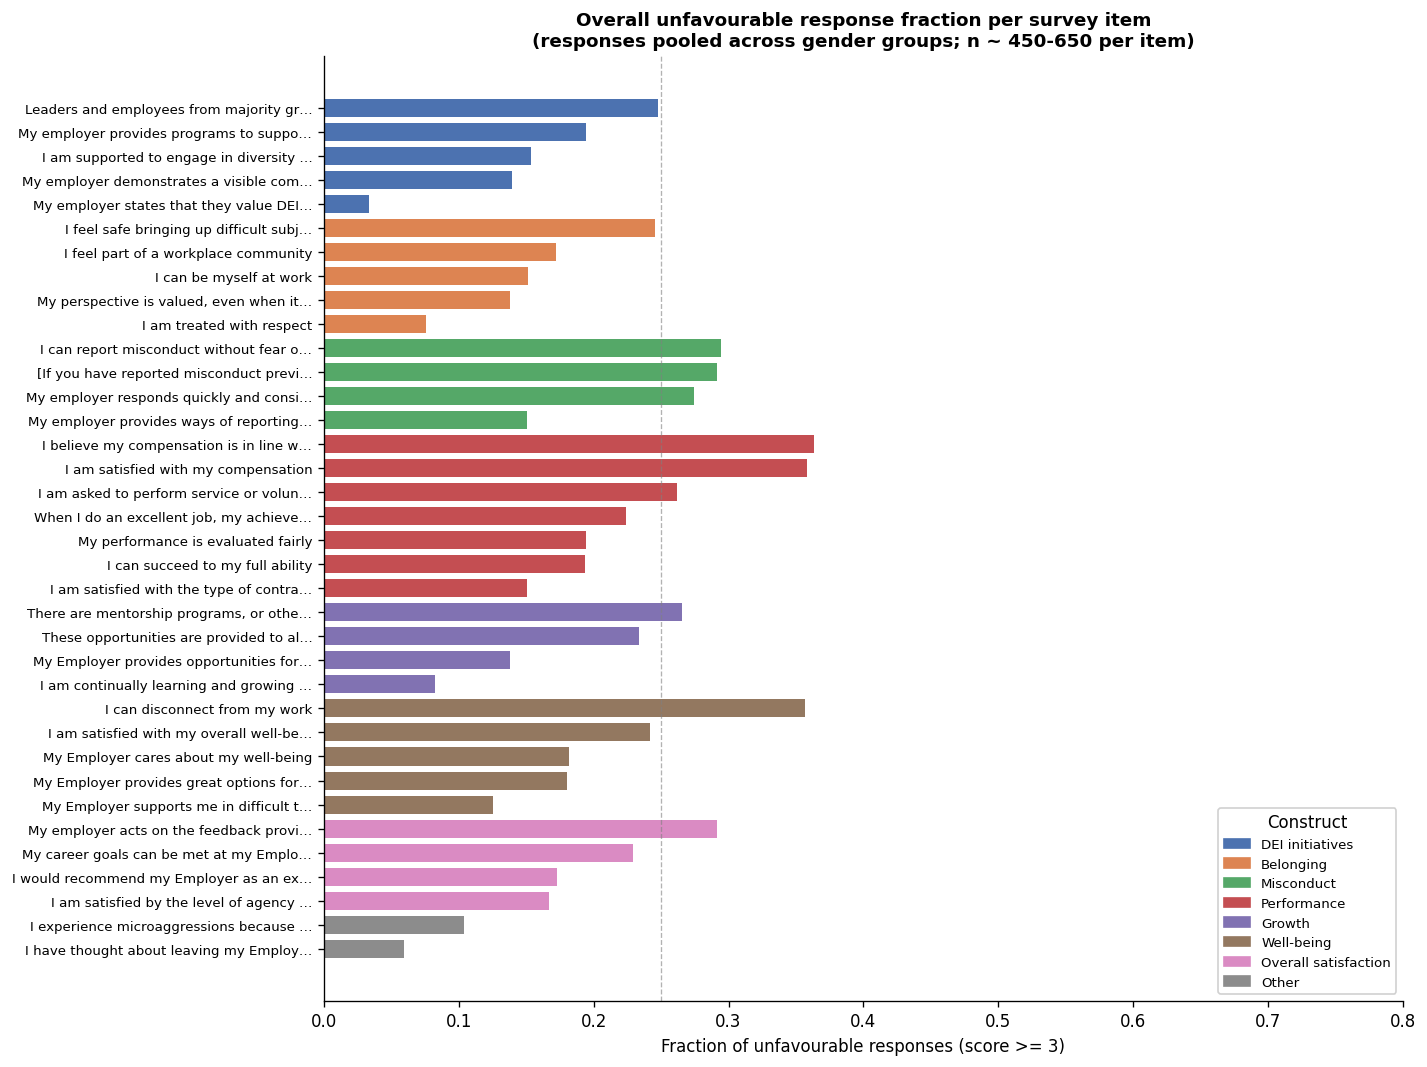


Top 5 items with highest unfavourable rates:
  0.364  I believe my compensation is in line w…
  0.358  I am satisfied with my compensation
  0.357  I can disconnect from my work
  0.294  I can report misconduct without fear o…
  0.291  [If you have reported misconduct previ…

Top 5 items with lowest unfavourable rates:
  0.034  My employer states that they value DEI…
  0.059  I have thought about leaving my Employ…
  0.076  I am treated with respect
  0.082  I am continually learning and growing …
  0.104  I experience microaggressions because …


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Overall (all-respondents) unfavourable fraction per item
#
# Strategy: pool Man + Woman + Other_genders columns from the Gender sheet.
# Independent shuffling makes pooling across gender groups equivalent to
# pooling across the full sample for items available in all gender groups.
# ─────────────────────────────────────────────────────────────────────────────

df_gender = sheets['Gender']
GENDER_GROUPS = ['Man', 'Woman', 'Other_genders']

overall_unfav = {}
for item in _all_items:
    parts = []
    for g in GENDER_GROUPS:
        col = f'{item} | {g}'
        if col in df_gender.columns:
            parts.append(df_gender[col].dropna())
    if parts:
        pooled = pd.concat(parts, ignore_index=True)
        overall_unfav[item] = unfav_fraction(pooled)

# ── Construct colour map ──────────────────────────────────────────────────────
CONSTRUCT_COLORS = {
    'DEI initiatives':     '#4C72B0',
    'Belonging':           '#DD8452',
    'Misconduct':          '#55A868',
    'Performance':         '#C44E52',
    'Growth':              '#8172B2',
    'Well-being':          '#937860',
    'Overall satisfaction':'#DA8BC3',
    'Other':               '#8C8C8C',
}

item_construct = {it: c for c, items in CONSTRUCTS.items() for it in items}
for it in _all_items:
    if it not in item_construct:
        item_construct[it] = 'Other'

# Order: by construct (paper order), then by unfav fraction descending within construct
ordered_items = []
for construct in list(CONSTRUCTS.keys()) + ['Other']:
    c_items = [(it, overall_unfav.get(it, np.nan))
               for it in _all_items if item_construct[it] == construct]
    c_items.sort(key=lambda x: -x[1])
    ordered_items.extend(c_items)

labels = [it[:48] + ('...' if len(it) > 48 else '') for it, _ in ordered_items]
values = [v for _, v in ordered_items]
colors = [CONSTRUCT_COLORS[item_construct[it]] for it, _ in ordered_items]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
y_pos = np.arange(len(labels))

ax.barh(y_pos, values, color=colors, edgecolor='none', height=0.75)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Fraction of unfavourable responses (score >= 3)', fontsize=10)
ax.set_title(
    'Overall unfavourable response fraction per survey item\n'
    '(responses pooled across gender groups; n ~ 450-650 per item)',
    fontsize=11, fontweight='bold'
)
ax.axvline(0.25, color='grey', ls='--', lw=0.8, alpha=0.6, label='25% reference')
ax.set_xlim(0, 0.80)

# Legend for constructs
legend_patches = [mpatches.Patch(color=CONSTRUCT_COLORS[c], label=c)
                  for c in list(CONSTRUCTS.keys()) + ['Other']]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8,
          framealpha=0.9, title='Construct')

plt.tight_layout()
plt.savefig('fig_overall_unfav_fraction.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 items with highest unfavourable rates:")
for it, v in sorted(overall_unfav.items(), key=lambda x: -x[1])[:5]:
    print(f"  {v:.3f}  {it}")
print("\nTop 5 items with lowest unfavourable rates:")
for it, v in sorted(overall_unfav.items(), key=lambda x: x[1])[:5]:
    print(f"  {v:.3f}  {it}")

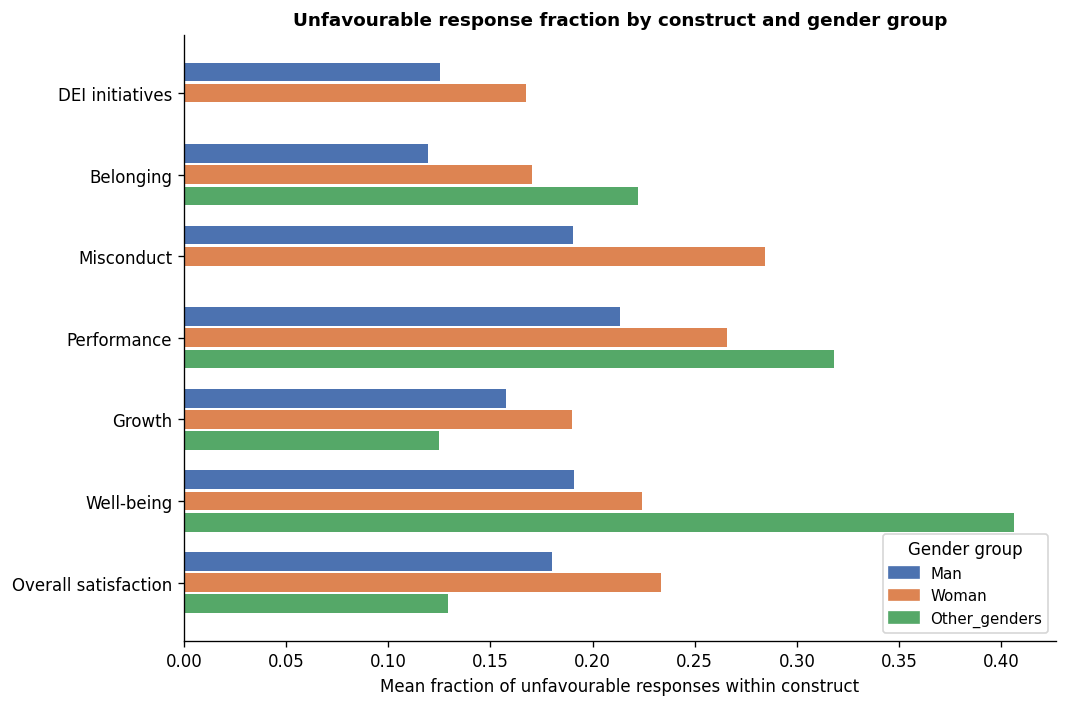


Mean unfavourable fraction by construct and gender group:
Construct                Man               Woman             Other_genders   
-----------------------------------------------------------------------------
DEI initiatives           0.125           0.167             N/A          
Belonging                 0.119           0.171           0.222          
Misconduct                0.191           0.284             N/A          
Performance               0.213           0.266           0.318          
Growth                    0.158           0.190           0.125          
Well-being                0.191           0.224           0.406          
Overall satisfaction      0.180           0.234           0.129          


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Unfavourable fraction by gender group, aggregated by construct
#
# Reproduces the construct-level bar chart used in Figure 12 of the paper.
# Each bar = mean of (unfavourable fraction per item) within the construct,
# computed separately per gender group.
# ─────────────────────────────────────────────────────────────────────────────

df_gender = sheets['Gender']
GENDER_COLOR_MAP = {
    'Man':          '#4C72B0',
    'Woman':        '#DD8452',
    'Other_genders':'#55A868'
}

# Compute mean unfavourable fraction per construct per gender group
construct_unfav_by_gender = {}
for construct, items in CONSTRUCTS.items():
    construct_unfav_by_gender[construct] = {}
    for g in GENDER_GROUPS:
        fracs = []
        for it in items:
            col = f'{it} | {g}'
            if col in df_gender.columns:
                frac = unfav_fraction(df_gender[col])
                if not np.isnan(frac):
                    fracs.append(frac)
        construct_unfav_by_gender[construct][g] = (
            float(np.mean(fracs)) if fracs else np.nan
        )

# ── Plot: grouped horizontal bar chart ────────────────────────────────────────
construct_names = list(CONSTRUCTS.keys())
n_constructs    = len(construct_names)
bar_height      = 0.26
y_base          = np.arange(n_constructs)

fig, ax = plt.subplots(figsize=(9, 6))

for i, g in enumerate(GENDER_GROUPS):
    offsets = y_base + (i - 1) * bar_height
    for j, c in enumerate(construct_names):
        val = construct_unfav_by_gender[c].get(g, np.nan)
        if not np.isnan(val):
            ax.barh(offsets[j], val, height=bar_height * 0.88,
                    color=GENDER_COLOR_MAP[g], edgecolor='none')

ax.set_yticks(y_base)
ax.set_yticklabels(construct_names, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mean fraction of unfavourable responses within construct', fontsize=10)
ax.set_title(
    'Unfavourable response fraction by construct and gender group',
    fontsize=11, fontweight='bold'
)

legend_patches = [mpatches.Patch(color=GENDER_COLOR_MAP[g], label=g)
                  for g in GENDER_GROUPS]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          title='Gender group')

plt.tight_layout()
plt.savefig('fig_unfav_by_gender_construct.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary table ────────────────────────────────────────────────────────
print("\nMean unfavourable fraction by construct and gender group:")
header = f"{'Construct':<24} " + "  ".join(f"{g:<16}" for g in GENDER_GROUPS)
print(header)
print("-" * len(header))
for c in construct_names:
    row = f"{c:<24} "
    for g in GENDER_GROUPS:
        v = construct_unfav_by_gender[c].get(g, np.nan)
        row += f"{v:>6.3f}          " if not np.isnan(v) else "   N/A          "
    print(row)

---
## Section 5 — Statistical analyses

This section reproduces the main inferential analyses from the paper:

1. **Analysis 1** — Chi-squared tests: effect of demographic factors on
   DEI-related leaving intention
2. **Analysis 2** — Chi-squared tests: effect of demographic factors on
   overall microaggression frequency
3. **Analysis 3** — Mann-Whitney U tests: disability status comparisons

All chi-squared analyses use **Holm-Bonferroni** correction for multiple
comparisons across demographic factors. Effect sizes are reported as
**Cramer's V**. Post-hoc power is estimated via the non-central chi-squared
distribution (non-centrality parameter λ = n × V²).

For MWU, effect size is **rank-biserial correlation r** and post-hoc power
uses the Cohen's d approximation (d = 2r / sqrt(1 − r²)).

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Analysis 1 — DEI-related leaving intention x demographic factors
#
# Paper result:
#   - Disability shows a significant effect; Age and Sexual_Orientation do not
#   - Gender effect NOT significant after Holm-Bonferroni correction
#     (paper reports p_holm = 0.174 for gender)
#
# Item: "I have thought about leaving my Employ..." (4-point Likert)
#   1=Strongly agree (seriously considering leaving) ... 4=Strongly disagree
# ─────────────────────────────────────────────────────────────────────────────

LEAVING_ITEM = 'I have thought about leaving my Employ…'

# Demographic sheets and groups to compare
LEAVING_DEMOGRAPHICS = {
    'Gender':             (['Man', 'Woman', 'Other_genders'], sheets['Gender']),
    'Age':                (['18-25', '26-35', '36-45', '46+'], sheets['Age']),
    'Sexual_Orientation': (['Straight', 'Bisexual', 'Other_SO'], sheets['Sexual_Orientation']),
    'Disability':         (['Abled', 'Disabled'], sheets['Disability']),
}

raw_ps    = []
stats_rows = []

for dem_name, (groups, sheet_df) in LEAVING_DEMOGRAPHICS.items():
    res = run_chi2_group(sheet_df, LEAVING_ITEM, groups)
    if res is None:
        print(f"  {dem_name}: insufficient data -- skipping")
        continue
    raw_ps.append(res['p'])
    stats_rows.append({
        'Demographic': dem_name,
        'n_groups':    len([g for g in groups
                            if f'{LEAVING_ITEM} | {g}' in sheet_df.columns]),
        'chi2':        res['chi2'],
        'df':          res['dof'],
        'p_raw':       res['p'],
        'n':           res['n'],
        "Cramer's V":  res['V'],
        'Power':       res['power'],
    })

# Holm-Bonferroni correction
if raw_ps:
    reject, p_holm, _, _ = multipletests(raw_ps, alpha=0.05, method='holm')
    for i, row in enumerate(stats_rows):
        row['p_holm']     = p_holm[i]
        row['Significant'] = 'Yes' if reject[i] else 'No'

results_df = pd.DataFrame(stats_rows)
col_order  = ['Demographic', 'n_groups', 'n', 'chi2', 'df', 'p_raw',
              'p_holm', "Cramer's V", 'Power', 'Significant']
results_df = results_df[col_order]

print("Analysis 1: DEI-related leaving intention x demographic factors")
print("Holm-Bonferroni correction applied across", len(raw_ps), "tests")
print("=" * 80)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n--- Contextual note ---")
print("The gender effect on leaving intention is NOT significant after")
print("Holm-Bonferroni correction. Paper reports p_holm = 0.174 for gender.")
print("Only Disability shows a significant effect at alpha=0.05 after correction.")
print("Age and Sexual_Orientation do not reach significance after Holm adjustment.")

# Descriptive: unfav fractions per group
print("\n--- Unfavourable fraction by group ---")
print(f"Item: '{LEAVING_ITEM}'")
for dem_name, (groups, sheet_df) in LEAVING_DEMOGRAPHICS.items():
    print(f"  {dem_name}:")
    for g in groups:
        col = f'{LEAVING_ITEM} | {g}'
        if col in sheet_df.columns:
            s    = sheet_df[col].dropna()
            frac = unfav_fraction(s)
            print(f"    {g:<18}  unfav={frac:.3f}  n={len(s)}")

Analysis 1: DEI-related leaving intention x demographic factors
Holm-Bonferroni correction applied across 4 tests
       Demographic  n_groups   n    chi2  df  p_raw  p_holm  Cramer's V  Power Significant
            Gender         3 657 12.1866   6 0.0579  0.1738      0.0963 0.4090          No
               Age         4 663 14.0057   9 0.1221  0.2442      0.0839 0.2623          No
Sexual_Orientation         3 584  7.7682   6 0.2556  0.2556      0.0816 0.2622          No
        Disability         2 638 18.5972   3 0.0003  0.0013      0.1707 0.9646         Yes

--- Contextual note ---
The gender effect on leaving intention is NOT significant after
Holm-Bonferroni correction. Paper reports p_holm = 0.174 for gender.
Only Disability shows a significant effect at alpha=0.05 after correction.
Age and Sexual_Orientation do not reach significance after Holm adjustment.

--- Unfavourable fraction by group ---
Item: 'I have thought about leaving my Employ…'
  Gender:
    Man                 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Analysis 2 -- Overall microaggression frequency x demographic factors
#
# Paper result: chi-squared tests across Gender, Age,
# Sexual Orientation, and Disability, with Holm-Bonferroni correction.
#
# Item: "I experience microaggressions because ..." (4-point Likert in
# the per-demographic sheets).
# Note: this is the OVERALL microaggression item on a 4-point Likert scale.
# The 14 detailed microaggression items on the 5-point frequency scale are
# available only in the pre-aggregated Figure_6_Microaggressions sheet.
# ─────────────────────────────────────────────────────────────────────────────

MICROAGG_ITEM = 'I experience microaggressions because …'

MICROAGG_DEMOGRAPHICS = {
    'Gender':             (['Man', 'Woman', 'Other_genders'], sheets['Gender']),
    'Age':                (['18-25', '26-35', '36-45', '46+'], sheets['Age']),
    'Sexual_Orientation': (['Straight', 'Bisexual', 'Other_SO'], sheets['Sexual_Orientation']),
    'Disability':         (['Abled', 'Disabled'], sheets['Disability']),
}

raw_ps_ma    = []
stats_rows_ma = []

for dem_name, (groups, sheet_df) in MICROAGG_DEMOGRAPHICS.items():
    # Only use groups for which the column is present
    available = [g for g in groups
                 if f'{MICROAGG_ITEM} | {g}' in sheet_df.columns]
    if len(available) < 2:
        print(f"  {dem_name}: item not available for >= 2 groups -- skipping")
        continue

    res = run_chi2_group(sheet_df, MICROAGG_ITEM, available)
    if res is None:
        print(f"  {dem_name}: insufficient data -- skipping")
        continue

    raw_ps_ma.append(res['p'])
    stats_rows_ma.append({
        'Demographic':    dem_name,
        'Groups':         ', '.join(available),
        'chi2':           res['chi2'],
        'df':             res['dof'],
        'p_raw':          res['p'],
        'n':              res['n'],
        "Cramer's V":     res['V'],
        'Power':          res['power'],
    })

# Holm-Bonferroni correction
if raw_ps_ma:
    reject_ma, p_holm_ma, _, _ = multipletests(raw_ps_ma, alpha=0.05, method='holm')
    for i, row in enumerate(stats_rows_ma):
        row['p_holm']      = p_holm_ma[i]
        row['Significant'] = 'Yes' if reject_ma[i] else 'No'

results_ma_df = pd.DataFrame(stats_rows_ma)
col_order_ma  = ['Demographic', 'Groups', 'n', 'chi2', 'df',
                 'p_raw', 'p_holm', "Cramer's V", 'Power', 'Significant']
results_ma_df = results_ma_df[col_order_ma]

print("Analysis 2: Overall microaggression frequency x demographic factors")
print("Holm-Bonferroni correction applied across", len(raw_ps_ma), "tests")
print("=" * 80)
print(results_ma_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Descriptive: unfav fractions per group
print("\n--- Unfavourable fraction by group ---")
print(f"Item: '{MICROAGG_ITEM}'")
for dem_name, (groups, sheet_df) in MICROAGG_DEMOGRAPHICS.items():
    avail = [g for g in groups
             if f'{MICROAGG_ITEM} | {g}' in sheet_df.columns]
    if not avail:
        continue
    print(f"  {dem_name}:")
    for g in avail:
        col  = f'{MICROAGG_ITEM} | {g}'
        s    = sheet_df[col].dropna()
        frac = unfav_fraction(s)
        print(f"    {g:<18}  unfav={frac:.3f}  n={len(s)}")

Analysis 2: Overall microaggression frequency x demographic factors
Holm-Bonferroni correction applied across 4 tests
       Demographic                       Groups   n     chi2  df  p_raw  p_holm  Cramer's V  Power Significant
            Gender    Man, Woman, Other_genders 684 102.3683   8 0.0000  0.0000      0.2736 0.9999         Yes
               Age     18-25, 26-35, 36-45, 46+ 694   9.9628  12 0.6192  0.6192      0.0692 0.1672          No
Sexual_Orientation Straight, Bisexual, Other_SO 602  35.5454   8 0.0000  0.0001      0.1718 0.8738         Yes
        Disability              Abled, Disabled 671  23.2317   4 0.0001  0.0002      0.1861 0.9834         Yes

--- Unfavourable fraction by group ---
Item: 'I experience microaggressions because …'
  Gender:
    Man                 unfav=0.042  n=214
    Woman               unfav=0.127  n=440
    Other_genders       unfav=0.200  n=30
  Age:
    18-25               unfav=0.108  n=120
    26-35               unfav=0.095  n=402
    36-4

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Analysis 3 -- Disability comparisons: Mann-Whitney U tests
#
# Paper cells:
#   Test 1: Does disability status affect perceived fairness of performance
#           evaluation?
#   Test 2: Does disability status affect overall microaggression frequency?
#
# Mann-Whitney U is appropriate for ordinal Likert data.
# Effect size: rank-biserial correlation r in [-1, 1].
#   r > 0: group_a (Abled) has higher (less favourable) scores
#   r < 0: group_b (Disabled) has higher (less favourable) scores
# Post-hoc power via Cohen's d approximation.
# ─────────────────────────────────────────────────────────────────────────────

df_dis         = sheets['Disability']
PERFORMANCE_ITEM = 'My performance is evaluated fairly'

print("Analysis 3: Disability x workplace outcomes (Mann-Whitney U)")
print("=" * 65)

# ── Test 1: Performance evaluation ───────────────────────────────────────────
print("\nTest 1: Disability status x 'My performance is evaluated fairly'")
print("  (group_a=Abled, group_b=Disabled)")
res1 = run_mwu_two(df_dis, PERFORMANCE_ITEM, 'Disabled', 'Abled', verbose=True)

if res1:
    # r_rb = 1 - 2U/(n1*n2).
    # r_rb > 0  <=> U < n1*n2/2  <=> group_a (Abled) stochastically SMALLER
    # Smaller Likert = more agreement = MORE favourable for Abled
    # Therefore Disabled respondents report LESS fair evaluation.
    mean_abled    = df_dis[f'{PERFORMANCE_ITEM} | Abled'].dropna().mean()
    mean_disabled = df_dis[f'{PERFORMANCE_ITEM} | Disabled'].dropna().mean()
    # Use mean (not median, which is tied at 2.0) and r_rb sign to confirm direction
    direction    = ("Disabled respondents report LESS fair evaluation "
                    "(higher mean Likert score; r_rb > 0 => Abled stochastically favoured)"
                    if res1['r'] > 0
                    else "Abled respondents report less fair evaluation")
    sig_str      = "SIGNIFICANT (p < 0.05)" if res1['p'] < 0.05 else "not significant"
    pow_str      = ("adequately powered (>= 0.80)" if res1['power'] >= 0.80
                    else "underpowered (< 0.80)")
    print(f"  Mean Abled={mean_abled:.2f}  Mean Disabled={mean_disabled:.2f}")
    print(f"  Direction: {direction}")
    print(f"  Result: {sig_str}")
    print(f"  Power:  {res1['power']:.3f} -- {pow_str}")

# ── Test 2: Microaggression frequency ────────────────────────────────────────
print("\nTest 2: Disability status x 'I experience microaggressions because ...'")
print("  (group_a=Abled, group_b=Disabled)")
res2 = run_mwu_two(df_dis, MICROAGG_ITEM, 'Disabled', 'Abled', verbose=True)

if res2:
    # r_rb > 0 => Abled stochastically SMALLER on this item.
    # For the microaggression item: 1=Never (favourable), 4=Strongly disagree.
    # Smaller score for Abled = Abled less frequently microaggressed.
    # Disabled has stochastically higher scores = MORE microaggressions.
    mean_abled    = df_dis[f'{MICROAGG_ITEM} | Abled'].dropna().mean()
    mean_disabled = df_dis[f'{MICROAGG_ITEM} | Disabled'].dropna().mean()
    direction    = ("Disabled respondents experience microaggressions MORE frequently "
                    "(higher mean Likert score; r_rb > 0 => Abled stochastically lower)"
                    if res2['r'] > 0
                    else "Abled respondents experience microaggressions more frequently")
    sig_str      = "SIGNIFICANT (p < 0.05)" if res2['p'] < 0.05 else "not significant"
    pow_str      = ("adequately powered (>= 0.80)" if res2['power'] >= 0.80
                    else "underpowered (< 0.80)")
    print(f"  Mean Abled={mean_abled:.2f}  Mean Disabled={mean_disabled:.2f}")
    print(f"  Direction: {direction}")
    print(f"  Result: {sig_str}")
    print(f"  Power:  {res2['power']:.3f} -- {pow_str}")

# ── Full descriptive table ────────────────────────────────────────────────────
print("\n--- Descriptive statistics ---")
for item, label in [(PERFORMANCE_ITEM, "Performance evaluation"),
                    (MICROAGG_ITEM,     "Microaggression frequency")]:
    print(f"  {label}:")
    for g in ['Disabled', 'Abled']:
        col = f'{item} | {g}'
        if col in df_dis.columns:
            s = df_dis[col].dropna()
            print(f"    {g:<10}  n={len(s):>3}  "
                  f"median={s.median():.1f}  "
                  f"mean={s.mean():.2f}  "
                  f"unfav={unfav_fraction(s):.3f}")

Analysis 3: Disability x workplace outcomes (Mann-Whitney U)

Test 1: Disability status x 'My performance is evaluated fairly'
  (group_a=Abled, group_b=Disabled)
  U=21126.0  p=0.0235  r=0.139  n1=584  n2=84  power=0.669
  Mean Abled=1.93  Mean Disabled=2.17
  Direction: Disabled respondents report LESS fair evaluation (higher mean Likert score; r_rb > 0 => Abled stochastically favoured)
  Result: SIGNIFICANT (p < 0.05)
  Power:  0.669 -- underpowered (< 0.80)

Test 2: Disability status x 'I experience microaggressions because ...'
  (group_a=Abled, group_b=Disabled)
  U=18814.5  p=0.0001  r=0.245  n1=586  n2=85  power=0.991
  Mean Abled=1.63  Mean Disabled=2.01
  Direction: Disabled respondents experience microaggressions MORE frequently (higher mean Likert score; r_rb > 0 => Abled stochastically lower)
  Result: SIGNIFICANT (p < 0.05)
  Power:  0.991 -- adequately powered (>= 0.80)

--- Descriptive statistics ---
  Performance evaluation:
    Abled       n=584  median=2.0  mean=1.93

---
## Section 6 — Figures from pre-aggregated data

The three summary sheets in the minimal dataset contain pre-aggregated
statistics that can be plotted directly. These represent exactly the data
behind the corresponding figures in the manuscript:

- **Figure 4** (`Figure_4_Intersectional`): Median unfavourable fraction and
  IQR across 35 items, by race × gender intersectional group
- **Figure 5** (`Figure_5_Accessibility`): Response-category proportions for
  three disability accessibility items (disabled respondents only)
- **Figure 6** (`Figure_6_Microaggressions`): Proportion who experienced each
  of 14 specific microaggression types (at least once), by minority group

These sheets were derived from the original individual-level data and are
provided here in aggregated form consistent with IRB privacy requirements.

Figure 4 source data:
     Race_group    Gender_group  n_respondents  Median_unfav_fraction  Q25_unfav_fraction  Q75_unfav_fraction
Racial_majority Gender_majority            159                 0.1554              0.1155              0.2021
Racial_majority Gender_minority            376                 0.2035              0.1580              0.3058
Racial_minority Gender_majority             88                 0.1882              0.1287              0.2325
Racial_minority Gender_minority            128                 0.2544              0.1826              0.3204


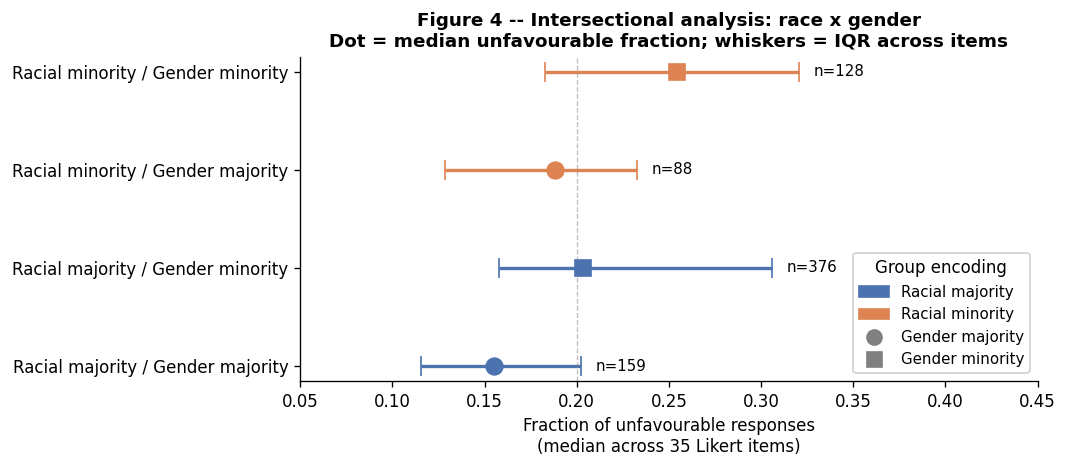


Key finding: racial minority / gender minority group has the
highest median unfavourable fraction, consistent with an additive
(and potentially multiplicative) disadvantage at the intersection.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 4 -- Intersectional analysis: race x gender
#
# Metric: fraction of unfavourable responses (score >= 3 on 4-point Likert)
# aggregated across all 35 general Likert items.
# Displayed as dot (median) + horizontal whiskers (Q25-Q75 IQR across items).
# ─────────────────────────────────────────────────────────────────────────────

df_fig4 = sheets['Figure_4_Intersectional']
print("Figure 4 source data:")
print(df_fig4[['Race_group', 'Gender_group', 'n_respondents',
               'Median_unfav_fraction', 'Q25_unfav_fraction',
               'Q75_unfav_fraction']].to_string(index=False))

# Build display labels
df_fig4 = df_fig4.copy()
df_fig4['label'] = (
    df_fig4['Race_group'].str.replace('_', ' ') + ' / ' +
    df_fig4['Gender_group'].str.replace('_', ' ')
)

# Visual encodings
race_colors = {
    'Racial_majority': '#4C72B0',
    'Racial_minority': '#DD8452'
}
gender_markers = {
    'Gender_majority': 'o',
    'Gender_minority': 's'
}

fig, ax = plt.subplots(figsize=(9, 4))

for _, row in df_fig4.iterrows():
    color  = race_colors[row['Race_group']]
    marker = gender_markers[row['Gender_group']]
    # Asymmetric xerr: [left_error, right_error]
    ax.errorbar(
        x=row['Median_unfav_fraction'],
        y=row['label'],
        xerr=[[row['Median_unfav_fraction'] - row['Q25_unfav_fraction']],
              [row['Q75_unfav_fraction']    - row['Median_unfav_fraction']]],
        fmt=marker, color=color, capsize=6, markersize=10,
        linewidth=2, elinewidth=2,
    )
    ax.text(row['Q75_unfav_fraction'] + 0.008, row['label'],
            f"n={row['n_respondents']}", va='center', ha='left', fontsize=9)

ax.set_xlabel(
    'Fraction of unfavourable responses\n(median across 35 Likert items)',
    fontsize=10
)
ax.set_title(
    'Figure 4 -- Intersectional analysis: race x gender\n'
    'Dot = median unfavourable fraction; whiskers = IQR across items',
    fontsize=11, fontweight='bold'
)
ax.axvline(0.20, color='grey', ls='--', lw=0.8, alpha=0.5,
           label='20% reference')
ax.set_xlim(0.05, 0.45)

# Custom legend
race_patches = [mpatches.Patch(color=c, label=r.replace('_', ' '))
                for r, c in race_colors.items()]
gender_lines = [
    plt.Line2D([0], [0], marker=m, color='grey', ls='none',
               markersize=9, label=g.replace('_', ' '))
    for g, m in gender_markers.items()
]
ax.legend(handles=race_patches + gender_lines, fontsize=9,
          loc='lower right', title='Group encoding', framealpha=0.9)

plt.tight_layout()
plt.savefig('fig4_intersectional.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey finding: racial minority / gender minority group has the")
print("highest median unfavourable fraction, consistent with an additive")
print("(and potentially multiplicative) disadvantage at the intersection.")

Figure 5 source data:
                                                                                                                                Item  n_respondents                                                   Scale  Prop_Strongly agree  Prop_Agree  Prop_Disagree  Prop_Strongly disagree
                                                                      I feel comfortable discussing physical or cognitive challenges             92 4-point Likert (1=Strongly agree … 4=Strongly disagree)               0.1196      0.4239         0.3261                  0.1304
                                                                                              My Employer accommodates my disability             74 4-point Likert (1=Strongly agree … 4=Strongly disagree)               0.2297      0.5270         0.1622                  0.0811
My Employer provides different options to support me in my role given my disability, e.g. flexible work arrangements and/or material             73 4-

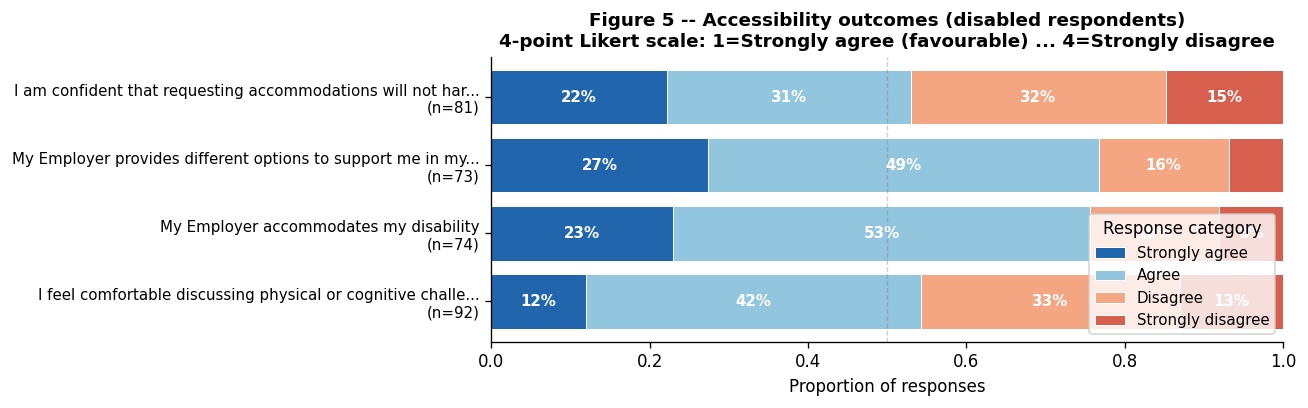


Key finding: most disabled respondents report accommodation and
support (favourable responses), but a substantial minority report
discomfort discussing challenges (~45% disagree or strongly disagree).


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 5 -- Accessibility outcomes (disabled respondents only)
#
# Three items from the accessibility module (not in per-demographic sheets):
#   1. Comfortable discussing physical or cognitive challenges
#   2. Employer accommodates disability
#   3. Employer provides flexible/material support options
#
# Displayed as horizontal stacked bar charts of response proportions.
# ─────────────────────────────────────────────────────────────────────────────

df_fig5 = sheets['Figure_5_Accessibility']
print("Figure 5 source data:")
print(df_fig5.to_string(index=False))

RESP_COLS   = ['Prop_Strongly agree', 'Prop_Agree',
               'Prop_Disagree',        'Prop_Strongly disagree']
RESP_LABELS = ['Strongly agree', 'Agree', 'Disagree', 'Strongly disagree']
# Diverging colour palette: blues for favourable, reds for unfavourable
RESP_COLORS = ['#2166ac', '#92c5de', '#f4a582', '#d6604d']

def shorten_item(text, maxlen=58):
    """Shorten item text for axis labels."""
    return text if len(text) <= maxlen else text[:maxlen] + '...'

item_labels = [shorten_item(it) for it in df_fig5['Item']]
n_items     = len(item_labels)
y_pos       = np.arange(n_items)

fig, ax = plt.subplots(figsize=(11, 3.5))

left = np.zeros(n_items)
for col, label, color in zip(RESP_COLS, RESP_LABELS, RESP_COLORS):
    widths = df_fig5[col].values
    ax.barh(y_pos, widths, left=left, color=color, label=label,
            edgecolor='white', linewidth=0.6)
    # Annotate proportion on segments wider than 7%
    for i, (w, l) in enumerate(zip(widths, left)):
        if w > 0.07:
            ax.text(l + w / 2, i, f'{w:.0%}',
                    ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    left += widths

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"{lab}\n(n={int(n)})"
     for lab, n in zip(item_labels, df_fig5['n_respondents'])],
    fontsize=9
)
ax.set_xlabel('Proportion of responses', fontsize=10)
ax.set_title(
    'Figure 5 -- Accessibility outcomes (disabled respondents)\n'
    '4-point Likert scale: 1=Strongly agree (favourable) ... 4=Strongly disagree',
    fontsize=11, fontweight='bold'
)
ax.axvline(0.5, color='grey', ls='--', lw=0.8, alpha=0.4)
ax.set_xlim(0, 1)
ax.legend(loc='lower right', fontsize=9, title='Response category')

plt.tight_layout()
plt.savefig('fig5_accessibility.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey finding: most disabled respondents report accommodation and")
print("support (favourable responses), but a substantial minority report")
print("discomfort discussing challenges (~45% disagree or strongly disagree).")

Figure 6 source data: 14 microaggression items x 5 minority groups


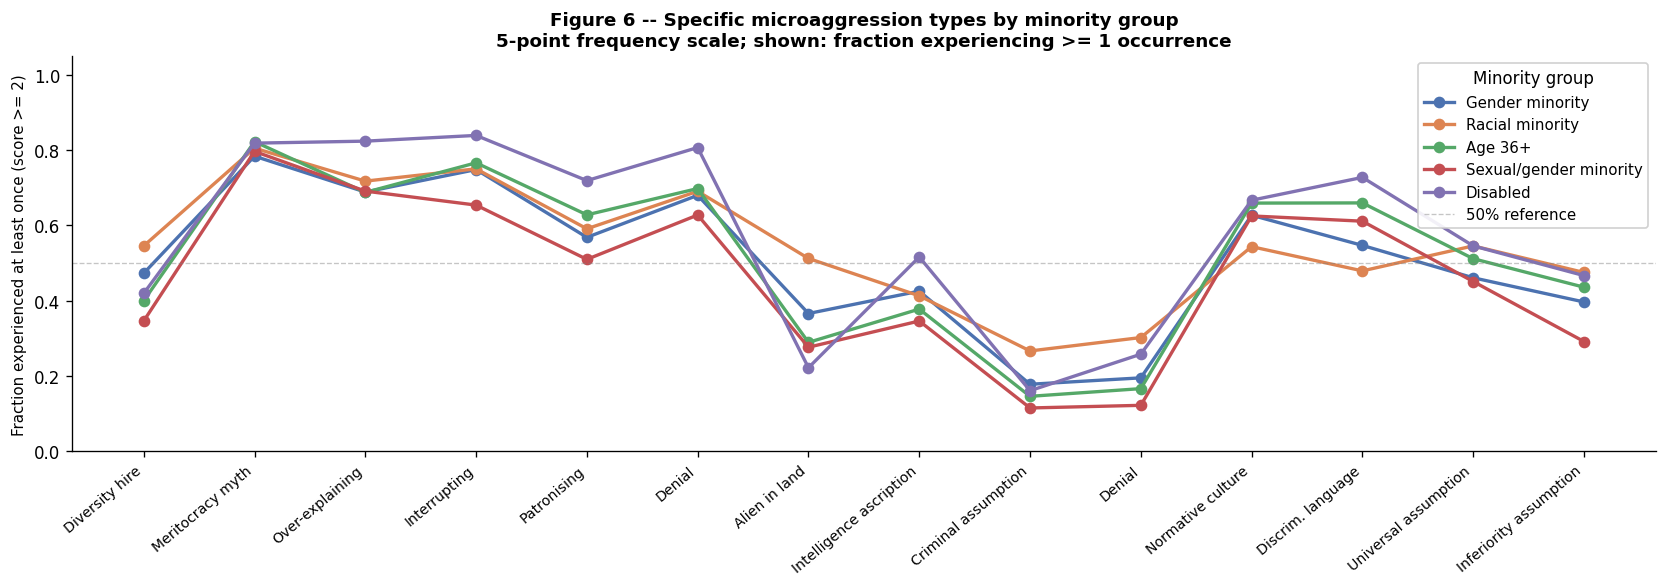


Highest unfavourable rate per minority group:
  Gender minority             : 0.784  -- Myth of meritocracy
  Racial minority             : 0.805  -- Myth of meritocracy
  Age 36+                     : 0.822  -- Myth of meritocracy
  Sexual/gender minority      : 0.796  -- Myth of meritocracy
  Disabled                    : 0.839  -- Interrupting

--- Average rates across all 14 items by group ---
  Gender minority             : mean unfav rate = 0.510
  Racial minority             : mean unfav rate = 0.545
  Age 36+                     : mean unfav rate = 0.518
  Sexual/gender minority      : mean unfav rate = 0.462
  Disabled                    : mean unfav rate = 0.571


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 6 -- Microaggression patterns by minority group
#
# For each of 14 specific microaggression types, shows the fraction of
# minority-group respondents who experienced it at least once (score >= 2
# on the 5-point frequency scale: 1=Never ... 5=Multiple times/day).
#
# Five minority groups are compared as separate lines across microagg types.
# ─────────────────────────────────────────────────────────────────────────────

df_fig6 = sheets['Figure_6_Microaggressions']
print(f"Figure 6 source data: {len(df_fig6)} microaggression items x 5 minority groups")

# Minority groups defined by (n_col, rate_col) pairs
MINORITY_GROUPS = {
    'Gender minority':        ('Gender_minority_n',   'Gender_minority_unfav_rate'),
    'Racial minority':        ('Racial_minority_n',   'Racial_minority_unfav_rate'),
    'Age 36+':                ('Age_36plus_n',        'Age_36plus_unfav_rate'),
    'Sexual/gender minority': ('Sex_or_minority_n',   'Sex_or_minority_unfav_rate'),
    'Disabled':               ('Disabled_n',          'Disabled_unfav_rate'),
}
GROUP_COLORS = {
    'Gender minority':        '#4C72B0',
    'Racial minority':        '#DD8452',
    'Age 36+':                '#55A868',
    'Sexual/gender minority': '#C44E52',
    'Disabled':               '#8172B2',
}

def ma_short_label(text):
    """Create a 2-4 word short label for microaggression items."""
    # Use the pre-defined short names where available
    short_map = {
        'Comments on diversity hires': 'Diversity hire',
        'Myth of meritocracy':         'Meritocracy myth',
        'Over-explaining':             'Over-explaining',
        'Interrupting':                'Interrupting',
        'Patronising':                 'Patronising',
        'Denial':                      'Denial',
        'Alien in own land':           'Alien in land',
        'Ascription of intelligence':  'Intelligence ascription',
        'Assumption of criminal':      'Criminal assumption',
        'Denial of bodily privacy':    'Bodily privacy',
        'Endorsement of normative':    'Normative culture',
        'Discriminatory language':     'Discrim. language',
        'Assumption of Universal':     'Universal assumption',
        'Assumptions of inferiority':  'Inferiority assumption',
    }
    for key, val in short_map.items():
        if key.lower() in text.lower():
            return val
    # Fallback: first 3 words
    return ' '.join(text.split()[:3]) + '...'

x_labels = [ma_short_label(it) for it in df_fig6['Item']]
x        = np.arange(len(x_labels))

fig, ax = plt.subplots(figsize=(14, 5))

for group_label, (n_col, rate_col) in MINORITY_GROUPS.items():
    if rate_col not in df_fig6.columns:
        continue
    rates = df_fig6[rate_col].values
    ax.plot(x, rates, marker='o', label=group_label,
            color=GROUP_COLORS[group_label], lw=2, markersize=6)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=40, ha='right', fontsize=8.5)
ax.set_ylabel('Fraction experienced at least once (score >= 2)', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title(
    'Figure 6 -- Specific microaggression types by minority group\n'
    '5-point frequency scale; shown: fraction experiencing >= 1 occurrence',
    fontsize=11, fontweight='bold'
)
ax.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.45,
           label='50% reference')
ax.legend(loc='upper right', fontsize=9, title='Minority group', framealpha=0.9)

plt.tight_layout()
plt.savefig('fig6_microaggressions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print highest-rate microaggression per group ───────────────────────────────
print("\nHighest unfavourable rate per minority group:")
for group_label, (n_col, rate_col) in MINORITY_GROUPS.items():
    if rate_col not in df_fig6.columns:
        continue
    idx = df_fig6[rate_col].idxmax()
    print(f"  {group_label:<28}: {df_fig6.loc[idx, rate_col]:.3f}  "
          f"-- {df_fig6.loc[idx, 'Item'][:60]}")

print("\n--- Average rates across all 14 items by group ---")
for group_label, (n_col, rate_col) in MINORITY_GROUPS.items():
    if rate_col not in df_fig6.columns:
        continue
    avg = df_fig6[rate_col].mean()
    print(f"  {group_label:<28}: mean unfav rate = {avg:.3f}")

---
## Section 7 — What cannot be reproduced

The following analyses from the paper **cannot** be reproduced from the minimal
dataset, for the reasons explained below.

---

### 1. Paired Wilcoxon signed-rank test (DEI items 9 vs 10)

**Paper analysis:** A paired Wilcoxon test compares each
respondent's scores on two related DEI items:
- Item 9: "My employer *states that they value* DEI initiatives"
- Item 10: "My employer *demonstrates a visible commitment* to DEI"

The test asks whether employers' stated values exceed their demonstrated
commitment — a within-person comparison.

**Why not reproducible:** This test requires both responses to come from the
*same individual*. Because each column is independently shuffled, a respondent's
answer to item 9 in row *i* is paired with a *different* respondent's answer
to item 10 in that same row. The within-person pairing is destroyed.

---

### 2. Cronbach's alpha (internal consistency)

**Paper analysis (Methods, Table 1):** Cronbach's α verified internal
consistency of the 7 constructs.

**Why not reproducible:** α requires the **inter-item covariance matrix**,
which captures how a single respondent's answers co-vary across items.
Independent column shuffling destroys all such covariance.


---

### 3. Employer-specific comparisons

**Paper analysis:** Multiple analyses examined differences between specific
named employers.

**Why not reproducible:** Employer names are excluded from the minimal dataset
to prevent re-identification of small organisations with distinctive demographic
profiles. Only the coarser `Academia` vs `Industry` distinction (available in
the `Employer_Type` sheet) can be reproduced.

---

### 4. Microaggression binary reporter analysis

**Paper analysis:** Respondents were classified as
"reporters" (ever experienced ≥ 1 microaggression, overall frequency > 1)
vs "non-reporters", and demographic composition of each group was analysed.

**Why not reproducible:** The binary reporter flag requires combining the
overall microaggression item with the detailed 14-item microaggression section.
Constructing this requires individual-level linkage between the two sections,
which is not possible from independently shuffled columns.

---

### 5. Non-disclosure analysis

**Paper analysis:** Rates of non-disclosure of sensitive demographic
characteristics (disability, sexual orientation) were examined in relation to
workplace experience scores, to characterise potential selection bias.

**Why not reproducible:** This analysis links a respondent's *decision to
disclose* a sensitive identity (a demographic attribute) to their *experience
scores* (survey item responses) — precisely the type of cross-dimension
individual linkage that the independent shuffling is designed to prevent.

---

> **Summary:** All five irreproducible analyses require either (a) within-person
> cross-item linkage (destroyed by independent shuffling), (b) employer
> identifiers (excluded for re-identification risk), or (c) derived individual-
> level flags depending on cross-dimension record linkage. None of these can be
> reproduced without access to the original restricted-access dataset, which cannot be shared due to IRB constraints.